# Da leitura à medida — análise do canal analógico

**Aula 05 · 26/08/2026 · Tópicos em Sistemas Computacionais I (IoT/AIoT) · UFPI**

No Laboratório 01 vocês imprimiram um número. Hoje a pergunta é outra: **aquele
número é verdade?**

Este notebook analisa o mesmo circuito de 24/08 — `3V3 → 10 kΩ → nó → LDR → GND`,
nó no GPIO34 — em três etapas:

| Parte | O quê | Onde isso aparece no sistema de vocês |
|---|---|---|
| 1 | **Caracterizar** o ruído com número, não com adjetivo | quantos bits dos 12 sobram de verdade |
| 2 | **Amostragem e aliasing**: o que a taxa decide | por que 500 Hz e não 100 Hz |
| 3 | **Filtrar**: média, mediana, exponencial — e o preço de cada uma | o `N` que vai para o firmware |
| 4 | **Calibrar**: transformar contagem em grandeza física | a linha de CSV que vira dataset no Módulo 3 |

> **Como usar.** Rode tudo (`Ambiente de execução → Executar tudo`) e depois leia
> célula por célula. As células marcadas **SUA VEZ** exigem uma decisão de vocês —
> é o que vai para o README da equipe. Não é preciso escrever pandas em sala; quem
> quiser mexer, mexa à vontade.

---
## Parte 0 — Preparação

Duas células: uma carrega as bibliotecas e define o estilo dos gráficos, a outra
localiza os dados. No Colab, envie o arquivo `dados_ruido_aula05.zip` quando for
pedido.

In [1]:
# --- bibliotecas, estilo e paleta -------------------------------------------
import os, glob, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Paleta categórica validada: azul, laranja, aqua. As três se distinguem também
# para quem tem daltonismo — por isso a ordem é fixa e não é sorteada.
AZUL, LARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
TINTA, TINTA2, MUDO = "#0b0b0b", "#52514e", "#8a8985"
SUPERFICIE, GRADE = "#fcfcfb", "#e8e7e3"

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE,
    "savefig.facecolor": SUPERFICIE, "figure.dpi": 110,
    "axes.edgecolor": MUDO, "axes.linewidth": 0.8,
    "axes.labelcolor": TINTA2, "axes.titlecolor": TINTA,
    "axes.titlesize": 11, "axes.titleweight": "semibold", "axes.titlepad": 10,
    "axes.labelsize": 9.5, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": TINTA2, "ytick.color": TINTA2,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "grid.color": GRADE, "grid.linewidth": 0.8, "axes.grid": True,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 1.8, "font.size": 10,
})

def limpa(ax):
    """Deixa a grade recessiva e atrás dos dados."""
    ax.set_axisbelow(True)
    return ax

print("bibliotecas prontas.")

bibliotecas prontas.


In [2]:
# --- onde estão os dados ----------------------------------------------------
PASTA = None
for candidata in ["dados", "../dados", "/content/dados", "."]:
    if glob.glob(os.path.join(candidata, "*.csv")):
        PASTA = candidata
        break

if PASTA is None:
    try:
        from google.colab import files
        print("Envie o arquivo dados_ruido_aula05.zip:")
        enviados = files.upload()
        with zipfile.ZipFile(next(iter(enviados))) as z:
            z.extractall("dados")
        PASTA = "dados"
    except ImportError:
        raise SystemExit("Coloque os CSV numa pasta 'dados' ao lado deste notebook.")

CENAS = sorted(os.path.splitext(os.path.basename(p))[0]
               for p in glob.glob(os.path.join(PASTA, "*.csv")))
print(f"dados em '{PASTA}':")
print("  " + " · ".join(CENAS))

dados em '../dados':
  ambiente · ambiente100 · ambiente2k · ambiente_rc · calibracao · degrau · emi · escuro · estavel · forte · saturado


In [3]:
# --- leitor: separa o cabeçalho de metadados dos dados -----------------------
def carrega(cena, pasta=None):
    """Devolve (metadados, DataFrame). O cabeçalho '#' vira um dicionário."""
    caminho = os.path.join(pasta or PASTA, f"{cena}.csv")
    meta, linhas, colunas = {}, [], None
    with open(caminho, encoding="utf-8") as fp:
        for linha in fp:
            linha = linha.strip()
            if not linha:
                continue
            if linha.startswith("#"):
                if "=" in linha:
                    chave, valor = linha[1:].split("=", 1)
                    meta[chave.strip()] = valor.strip()
            elif linha[0].isalpha():
                colunas = [c.strip() for c in linha.split(",")]
            else:
                linhas.append([float(x) for x in linha.split(",")])
    df = pd.DataFrame(linhas, columns=colunas)
    # conveniências derivadas do cabeçalho
    meta["lsb_mv"] = float(meta.get("lsb_nominal_mv", 3300 / 4096))
    if "bruto" in df:
        df["mv"] = df["bruto"] * meta["lsb_mv"]
    if "t_us" in df:
        df["t_s"] = df["t_us"] / 1e6
    return meta, df

meta, df = carrega("ambiente")
print("cena:", meta["cena"], "| origem:", meta.get("origem", "?"),
      "| taxa:", meta["taxa_hz"], "Hz | n:", meta["n"])
df.head()

cena: ambiente | origem: sintetico | taxa: 500 Hz | n: 5000


,n,t_us,bruto,mv,t_s
0,0.0,2.0,1625.0,1309.2625,0.000002
1,1.0,1999.0,1612.0,1298.7884,0.001999
2,2.0,4002.0,1607.0,1294.7599,0.004002
3,3.0,6001.0,1620.0,1305.2340,0.006001
4,4.0,8002.0,1622.0,1306.8454,0.008002


> **Repare na linha `origem`.** Este conjunto foi **gerado por um modelo físico**,
> não medido em bancada — e o arquivo declara isso. Um conjunto de dados sem
> procedência declarada não serve para nada. Vocês vão ouvir isso de novo no
> Módulo 3, quando o dataset for de vocês.

---
## Parte 1 — Caracterizar: o ruído em número

Três grandezas bastam para descrever o piso de ruído de um canal:

- **σ (desvio padrão)** — a dispersão típica em torno da média. É o número que
  interessa, porque é ele que cai quando você filtra.
- **pico a pico** — o pior caso observado. Sempre bem maior que σ, e é ele que
  faz o LED piscar sozinho quando o limiar está mal escolhido.
- **ENOB (bits efetivos)** — quantos dos 12 bits do ADC carregam informação e não
  ruído. Se o σ vale 8 contagens, os 3 bits de baixo são decoração.

$$\text{ENOB} = 12 - \log_2\!\left(\frac{\sigma}{\sigma_q}\right),
\qquad \sigma_q = \frac{1}{\sqrt{12}} \approx 0{,}289\ \text{contagens}$$

onde $\sigma_q$ é o ruído de quantização — o piso teórico, o melhor que um ADC de
12 bits perfeito conseguiria.

In [4]:
# --- tabela de caracterização de todas as cenas -----------------------------
SIGMA_Q = 1 / np.sqrt(12)   # ruído de quantização, em contagens

def caracteriza(cena):
    meta, df = carrega(cena)
    x = df["bruto"].values
    lsb = meta["lsb_mv"]
    return {
        "cena": cena,
        "taxa (Hz)": int(float(meta["taxa_hz"])),
        "n": len(x),
        "média": round(x.mean(), 1),
        "σ (cont.)": round(x.std(), 2),
        "σ (mV)": round(x.std() * lsb, 2),
        "p-p": int(x.max() - x.min()),
        "ENOB": round(12 - np.log2(max(x.std(), SIGMA_Q) / SIGMA_Q), 2),
    }

tabela = pd.DataFrame([caracteriza(c) for c in CENAS if c != "calibracao"])
tabela = tabela.sort_values("σ (cont.)").reset_index(drop=True)
tabela

,cena,taxa (Hz),n,média,σ (cont.),σ (mV),p-p,ENOB
0,saturado,500,3000,3908.5,1.94,1.57,14,9.25
1,estavel,500,5000,1645.9,2.54,2.05,18,8.86
2,forte,500,5000,395.3,2.62,2.11,21,8.82
3,escuro,500,5000,3805.0,2.68,2.16,19,8.78
4,ambiente_rc,500,5000,1618.0,3.30,2.66,21,8.48
5,ambiente2k,2000,4000,1617.6,5.77,4.65,29,7.68
6,ambiente100,100,1000,1619.6,5.88,4.74,29,7.65
7,ambiente,500,5000,1617.2,6.08,4.90,36,7.60
8,emi,500,5000,1619.3,7.53,6.07,214,7.29
9,degrau,500,5000,2658.1,1049.48,845.57,2131,0.17


**Leia a tabela antes de seguir.** Três coisas devem incomodar:

1. Nenhuma cena chega perto de 12 bits efetivos. O melhor caso perde mais de
   3 bits só para o ruído — e isso **antes** de qualquer erro de calibração.
2. A cena `saturado` tem o **menor** σ de todas. Ruído baixo não é sinônimo de
   medida boa: ali o sinal está comprimido contra o teto da faixa útil, e o que
   sumiu junto com o ruído foi a informação.
3. A cena `emi` tem σ moderado mas pico a pico enorme. Média e desvio padrão não
   contam a história toda quando o ruído é impulsivo — guarde isso para a Parte 3.

E uma quarta, que é uma armadilha: a cena `degrau` fecha a tabela com σ de mil
contagens e ENOB de 0,17 bit. O ADC não piorou — é que ali σ está medindo a
**transição**, não o ruído. **Estatística de cena não estacionária não significa
nada.** Antes de calcular qualquer coisa, verifique se a cena tem um regime só.
É o primeiro cuidado de qualquer campanha de coleta, e o erro mais comum nela.

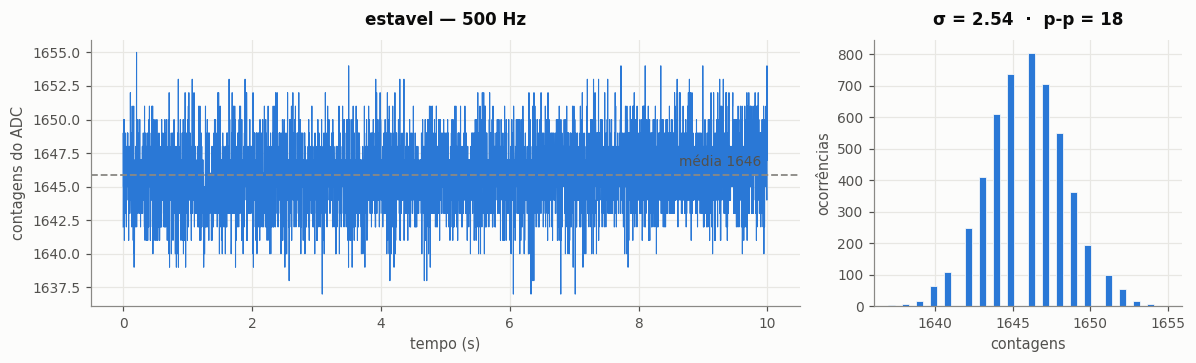

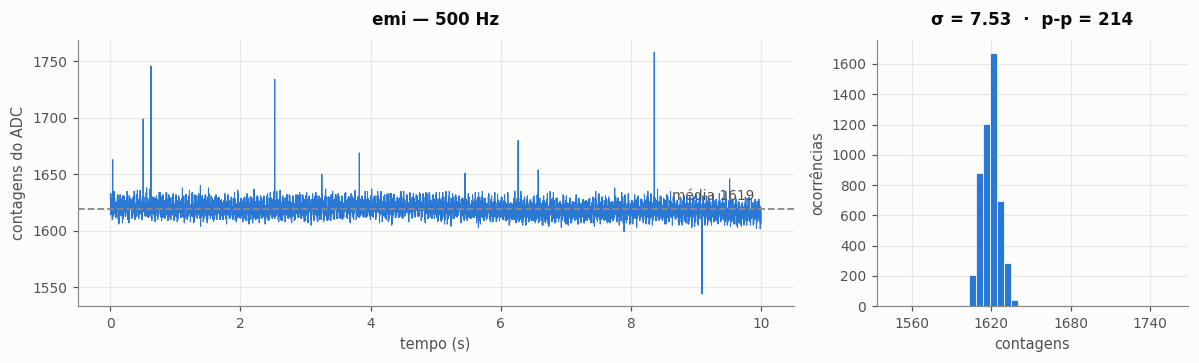

In [5]:
# --- retrato de uma cena: série no tempo + histograma -----------------------
def retrato(cena, recorte_s=None):
    meta, df = carrega(cena)
    x, t = df["bruto"].values, df["t_s"].values
    if recorte_s:
        m = t <= recorte_s
        x_plot, t_plot = x[m], t[m]
    else:
        x_plot, t_plot = x, t

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.4),
                                   gridspec_kw={"width_ratios": [2.3, 1]})
    limpa(ax1).plot(t_plot, x_plot, color=AZUL, lw=0.7)
    ax1.axhline(x.mean(), color=MUDO, lw=1.2, ls="--")
    ax1.annotate(f"média {x.mean():.0f}", xy=(t_plot[-1], x.mean()),
                 xytext=(-4, 6), textcoords="offset points",
                 ha="right", color=TINTA2, fontsize=9)
    ax1.set_xlabel("tempo (s)"); ax1.set_ylabel("contagens do ADC")
    ax1.set_title(f"{cena} — {int(float(meta['taxa_hz']))} Hz")

    limpa(ax2).hist(x, bins=40, color=AZUL, edgecolor=SUPERFICIE, linewidth=0.5)
    ax2.set_xlabel("contagens"); ax2.set_ylabel("ocorrências")
    ax2.set_title(f"σ = {x.std():.2f}  ·  p-p = {int(x.max()-x.min())}")
    ax2.xaxis.set_major_locator(MaxNLocator(4))
    fig.tight_layout(); plt.show()

retrato("estavel")
retrato("emi")

As duas cenas têm σ da mesma ordem, mas o histograma denuncia a diferença: em
`estavel` a distribuição é um sino limpo; em `emi` o sino tem **caudas** — são os
impulsos acoplados pelo fio. O tipo de ruído decide o filtro, e nenhuma das duas
informações estava no valor de σ sozinho.

### SUA VEZ — 1

Rode `retrato("...")` para `escuro`, `forte` e `saturado`. Depois responda no
README da equipe:

- O σ em **contagens** de `forte` é menor que o de `escuro`. Isso significa que a
  medida de luz forte é mais precisa? *(Dica: olhe onde cada cena cai na escala e
  lembre da forma do divisor.)*
- Em `saturado`, o que aconteceu com a faixa útil do ADC?

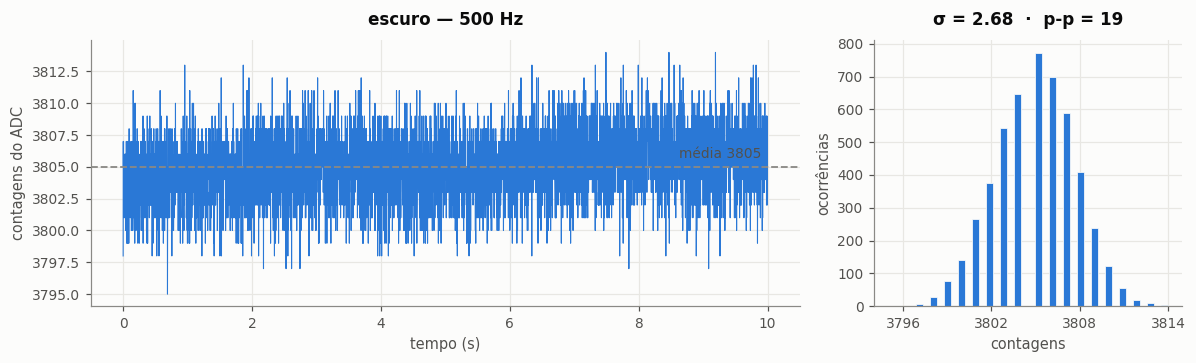

In [6]:
# SUA VEZ: rodando para as três cenas pedidas.
retrato("escuro")


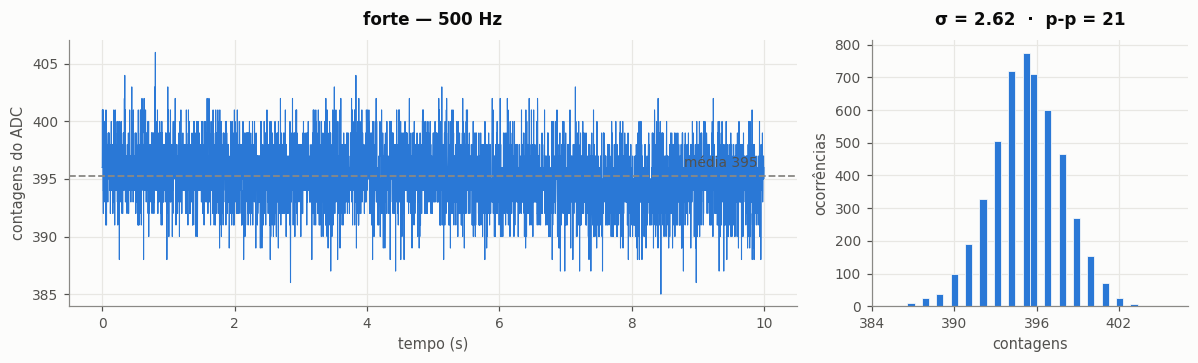

In [7]:
retrato("forte")

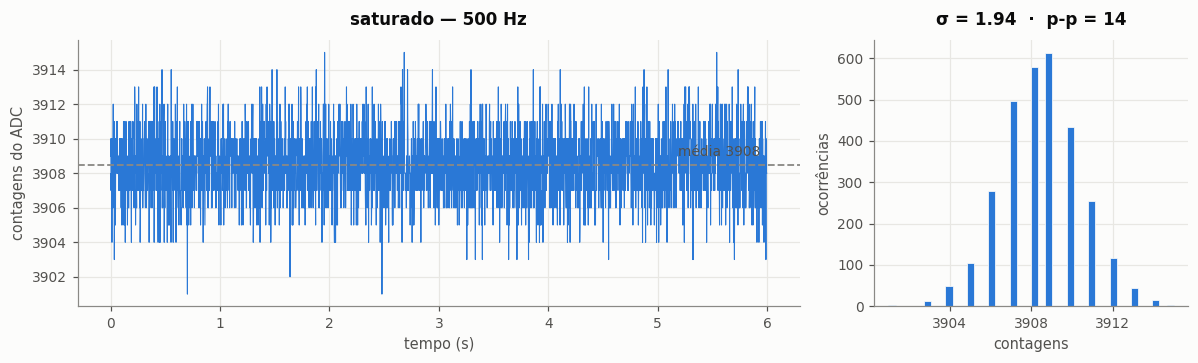

In [8]:
retrato("saturado")

In [9]:
# comparação numérica das três cenas, em contagens e em mV
comp = pd.DataFrame([caracteriza(c) for c in ["escuro", "forte", "saturado"]])
comp


,cena,taxa (Hz),n,média,σ (cont.),σ (mV),p-p,ENOB
0,escuro,500,5000,3805.0,2.68,2.16,19,8.78
1,forte,500,5000,395.3,2.62,2.11,21,8.82
2,saturado,500,3000,3908.5,1.94,1.57,14,9.25


---
## Parte 2 — Amostragem: o que a taxa decide

**Nyquist.** Amostrando a $f_s$, o máximo que se pode representar é $f_s/2$.
Qualquer coisa acima disso não desaparece: ela **volta rebatida** para dentro da
banda, disfarçada de uma frequência que nunca existiu. Isso é *aliasing*, e é
irreversível — nenhum filtro digital desfaz, porque a informação já foi destruída
no instante da amostragem.

As cenas `ambiente`, `ambiente2k` e `ambiente100` são **o mesmo fenômeno físico**:
a mesma lâmpada, o mesmo LDR, a mesma sala. Só muda a taxa. Compare os três
espectros antes de concluir qualquer coisa sobre o que está na sala.

In [10]:
# --- antes de qualquer FFT: a taxa nominal foi mesmo respeitada? ------------
for cena in ["ambiente", "ambiente2k", "ambiente100"]:
    meta, df = carrega(cena)
    periodo_nominal = float(meta["periodo_us"])
    intervalos = np.diff(df["t_us"].values)
    print(f"{cena:<12} período nominal={periodo_nominal:6.0f} us  "
          f"medido={intervalos.mean():7.1f} ± {intervalos.std():4.1f} us  "
          f"pior desvio declarado={meta['jitter_max_us']} us")

ambiente     período nominal=  2000 us  medido= 2000.0 ±  2.8 us  pior desvio declarado=31 us
ambiente2k   período nominal=   500 us  medido=  500.0 ±  2.8 us  pior desvio declarado=34 us
ambiente100  período nominal= 10000 us  medido=10000.0 ±  2.7 us  pior desvio declarado=31 us


O jitter é de poucas dezenas de microssegundos contra um período de milissegundos
— desprezível, e agora sabemos disso em vez de supor. **Essa conferência não é
opcional:** a FFT abaixo usa a taxa nominal, e se o jitter fosse grande todo o
eixo de frequência estaria errado.

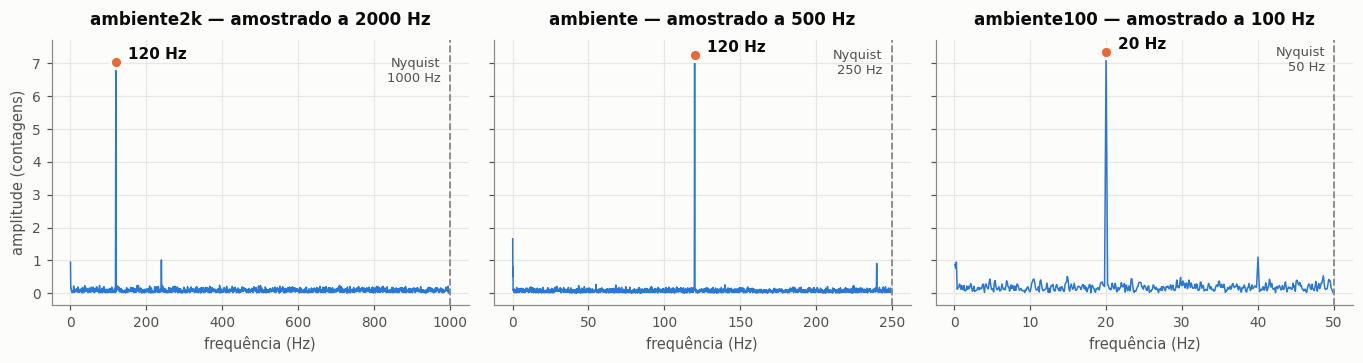

In [11]:
# --- espectro de amplitude --------------------------------------------------
def espectro(x, fs):
    """Amplitude por frequência. A janela de Hann evita que o início e o fim
    abruptos do registro criem energia falsa espalhada por todo o espectro."""
    x = x - x.mean()
    janela = np.hanning(len(x))
    amp = np.abs(np.fft.rfft(x * janela)) * 2 / np.sum(janela)
    freq = np.fft.rfftfreq(len(x), 1 / fs)
    return freq, amp

fig, eixos = plt.subplots(1, 3, figsize=(12.5, 3.4), sharey=True)
for ax, cena in zip(eixos, ["ambiente2k", "ambiente", "ambiente100"]):
    meta, df = carrega(cena)
    fs = float(meta["taxa_hz"])
    freq, amp = espectro(df["bruto"].values, fs)
    limpa(ax).plot(freq[1:], amp[1:], color=AZUL, lw=1.0)

    i = 1 + int(np.argmax(amp[1:]))
    ax.plot(freq[i], amp[i], "o", ms=8, color=LARANJA,
            markeredgecolor=SUPERFICIE, markeredgewidth=2, zorder=3)
    ax.annotate(f"{freq[i]:.0f} Hz", xy=(freq[i], amp[i]),
                xytext=(8, 2), textcoords="offset points",
                color=TINTA, fontsize=10, fontweight="semibold")
    ax.axvline(fs / 2, color=MUDO, lw=1.2, ls="--")
    ax.annotate(f"Nyquist\n{fs/2:.0f} Hz", xy=(fs / 2, ax.get_ylim()[1]),
                xytext=(-6, -4), textcoords="offset points",
                ha="right", va="top", color=TINTA2, fontsize=8.5)
    ax.set_title(f"{cena} — amostrado a {fs:.0f} Hz")
    ax.set_xlabel("frequência (Hz)")
eixos[0].set_ylabel("amplitude (contagens)")
fig.tight_layout(); plt.show()

### O que aconteceu

A 2 kHz e a 500 Hz o pico está em **120 Hz** — a lâmpada de LED pisca no dobro da
frequência da rede, porque a ponte retificadora entrega dois pulsos por ciclo de
60 Hz. Fisicamente correto, e é isso que está na sala.

A 100 Hz, Nyquist vale 50 Hz. Os 120 Hz **não cabem**, e a energia reaparece em
$|120 - 100| = 20\ \text{Hz}$ — uma frequência que não existe em lugar nenhum da
sala. Quem só tivesse `ambiente100.csv` concluiria, com toda a convicção do mundo,
que a lâmpada oscila a 20 Hz.

**A consequência de projeto.** Não adianta filtrar depois: o remédio é amostrar
mais rápido ou pôr um filtro **analógico** antes do ADC — um RC que atenue o que
está acima de $f_s/2$ enquanto o sinal ainda é contínuo. É por isso que a cena
`ambiente_rc` existe, e é o que vamos medir na Parte 3.

---
## Parte 3 — Filtrar, e pagar por isso

Três filtros, três comportamentos:

| Filtro | Como funciona | Custa |
|---|---|---|
| **Média móvel de N** | soma as N últimas e divide | N amostras de atraso; um único impulso contamina N leituras |
| **Mediana de N** | ordena as N últimas e pega a do meio | ordenação a cada amostra; ligeiramente pior que a média em ruído gaussiano |
| **Exponencial (EMA)** | `y ← y + α·(x − y)` | uma multiplicação e uma variável; nunca esquece de todo |

A média móvel tem uma propriedade que vale decorar: para ruído **branco**,

$$\sigma_{\text{filtrado}} = \frac{\sigma_0}{\sqrt{N}}$$

Quadruplicar N corta o ruído pela metade e quadruplica o atraso. Esse é o
compromisso, e ele é seu para escolher — não do filtro.

In [12]:
# --- os três filtros --------------------------------------------------------
def media_movel(x, N):
    """Média das N últimas amostras. O início vira NaN para manter o alinhamento
    temporal com o sinal bruto — sem isso, os gráficos ficam deslocados."""
    if N <= 1:
        return x.astype(float)
    acum = np.cumsum(np.insert(x.astype(float), 0, 0.0))
    y = (acum[N:] - acum[:-N]) / N
    return np.concatenate([np.full(N - 1, np.nan), y])

def mediana_movel(x, N):
    if N <= 1:
        return x.astype(float)
    janelas = np.lib.stride_tricks.sliding_window_view(x.astype(float), N)
    return np.concatenate([np.full(N - 1, np.nan), np.median(janelas, axis=1)])

def ema(x, alfa):
    """y[i] = y[i-1] + alfa*(x[i] - y[i-1]). Custa uma variável de estado."""
    y = np.empty(len(x), dtype=float)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = y[i - 1] + alfa * (x[i] - y[i - 1])
    return y

teste = carrega("estavel")[1]["bruto"].values
print(f"bruto σ={teste.std():.2f}  |  média de 8 σ={np.nanstd(media_movel(teste,8)):.2f}"
      f"  |  mediana de 8 σ={np.nanstd(mediana_movel(teste,8)):.2f}"
      f"  |  EMA α=0,1 σ={ema(teste,0.1).std():.2f}")

bruto σ=2.54  |  média de 8 σ=0.92  |  mediana de 8 σ=1.07  |  EMA α=0,1 σ=0.66


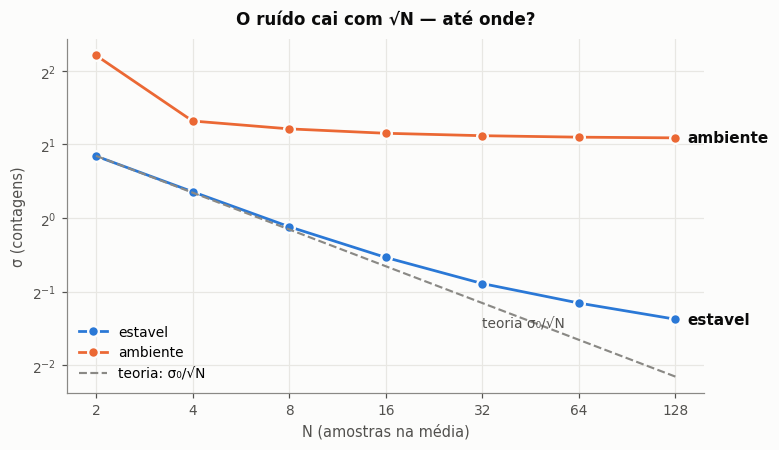

σ medido         σ previsto            razão        
cena ambiente estavel   ambiente estavel ambiente estavel
N                                                        
2        4.63    1.79       4.30    1.80     1.08    1.00
4        2.49    1.28       3.04    1.27     0.82    1.01
8        2.32    0.92       2.15    0.90     1.08    1.03
16       2.22    0.69       1.52    0.64     1.46    1.09
32       2.17    0.54       1.08    0.45     2.02    1.20
64       2.14    0.45       0.76    0.32     2.82    1.41
128      2.13    0.39       0.54    0.22     3.96    1.72

In [13]:
# --- a lei do 1/raiz(N): vale sempre? ---------------------------------------
ENES = [2, 4, 8, 16, 32, 64, 128]

fig, ax = plt.subplots(figsize=(7.2, 4.2))
resumo = []
for cena, cor in [("estavel", AZUL), ("ambiente", LARANJA)]:
    x = carrega(cena)[1]["bruto"].values
    s0 = x.std()
    sigmas = [np.nanstd(media_movel(x, N)) for N in ENES]
    limpa(ax).plot(ENES, sigmas, "-o", color=cor, ms=7,
                   markeredgecolor=SUPERFICIE, markeredgewidth=1.5, label=cena)
    ax.annotate(cena, xy=(ENES[-1], sigmas[-1]), xytext=(8, 0),
                textcoords="offset points", color=TINTA, fontsize=10,
                fontweight="semibold", va="center")
    for N, s in zip(ENES, sigmas):
        resumo.append({"cena": cena, "N": N, "σ medido": round(s, 2),
                       "σ previsto": round(s0 / np.sqrt(N), 2),
                       "razão": round(s / (s0 / np.sqrt(N)), 2),
                       "latência (ms)": round(N / 500 * 1000, 1)})

x_ref = carrega("estavel")[1]["bruto"].values
ax.plot(ENES, [x_ref.std() / np.sqrt(N) for N in ENES], ls="--", color=MUDO,
        lw=1.4, label="teoria: σ₀/√N")
ax.annotate("teoria σ₀/√N", xy=(ENES[-3], x_ref.std() / np.sqrt(ENES[-3])),
            xytext=(0, -16), textcoords="offset points", color=TINTA2, fontsize=9)
ax.set_xscale("log", base=2); ax.set_yscale("log", base=2)
ax.set_xticks(ENES); ax.set_xticklabels(ENES)
ax.set_xlabel("N (amostras na média)"); ax.set_ylabel("σ (contagens)")
ax.set_title("O ruído cai com √N — até onde?")
ax.legend(loc="lower left")
fig.tight_layout(); plt.show()

pd.DataFrame(resumo).pivot(index="N", columns="cena",
                           values=["σ medido", "σ previsto", "razão"])

### O resultado mais importante da aula

Na cena **`estavel`** a lei vale: a razão entre medido e previsto fica em torno de
1,0 até N ≈ 16. O ruído ali é praticamente branco, e a média faz exatamente o que
a teoria promete.

Na cena **`ambiente`** a curva **trava**. A partir de N ≈ 8 aumentar a janela não
adianta mais: σ encosta num piso e fica lá, por mais que você aumente N e pague o
atraso. Esse piso é a **deriva lenta** — a variação da lâmpada e da temperatura ao
longo dos 10 segundos.

E aqui está a lição: **filtro não remove deriva.** Um filtro passa-baixas separa o
que é rápido do que é lento — e a deriva é lenta, como o seu sinal. Aumentar N só
troca ruído por atraso, sem ganhar exatidão. Deriva se resolve com **calibração**
e com **referência**, que é a Parte 4.

Quem aumentar N até 128 no firmware vai pagar 256 ms de atraso para não ganhar
nada. Vale medir antes de escolher.

**Um detalhe que vale ouro.** Olhem a linha de `ambiente` em N = 4: a razão cai
*abaixo* de 1 — o filtro foi melhor que a teoria. Não é acaso. Uma média móvel de
N amostras tem um **zero** em $f_s/N$, e $500/4 = 125$ Hz cai quase em cima dos
120 Hz do flicker da lâmpada. A média móvel não é só um passa-baixas: ela é
também um rejeita-faixa, e **quem escolhe N escolhe onde ficam os zeros**. Com
uma taxa de amostragem múltipla de 120 Hz dá para matar o flicker da rede de
graça — é assim que multímetros de bancada fazem.

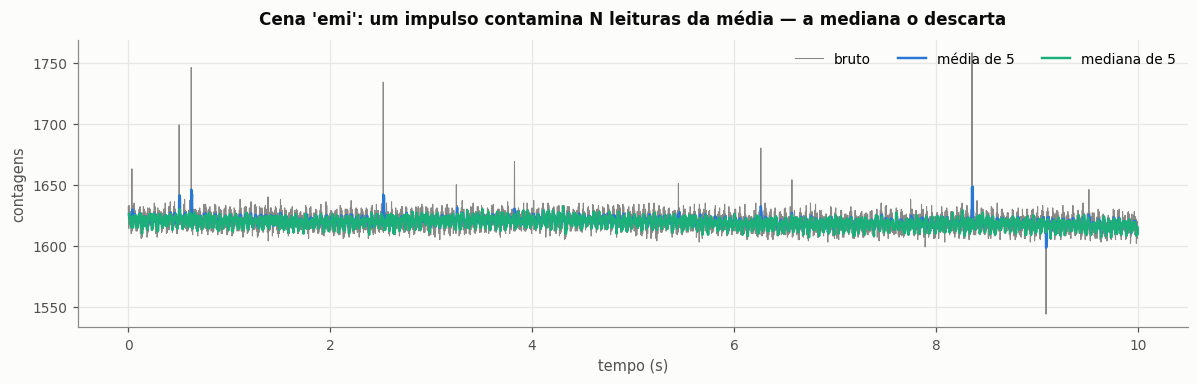

,sinal,σ,pico a pico
0,bruto,7.53,214
1,média de 5,3.72,50
2,mediana de 5,3.85,26


In [14]:
# --- ruído impulsivo: média ou mediana? -------------------------------------
meta, df = carrega("emi")
x, t = df["bruto"].values, df["t_s"].values
N = 5
mm, md_ = media_movel(x, N), mediana_movel(x, N)

fig, ax = plt.subplots(figsize=(11, 3.6))
limpa(ax).plot(t, x, color=MUDO, lw=0.7, label="bruto", zorder=1)
ax.plot(t, mm, color=AZUL, lw=1.6, label=f"média de {N}", zorder=2)
ax.plot(t, md_, color=AQUA, lw=1.6, label=f"mediana de {N}", zorder=3)
ax.set_xlabel("tempo (s)"); ax.set_ylabel("contagens")
ax.set_title("Cena 'emi': um impulso contamina N leituras da média — a mediana o descarta")
ax.legend(loc="upper right", ncol=3)
fig.tight_layout(); plt.show()

pd.DataFrame([
    {"sinal": "bruto", "σ": round(x.std(), 2), "pico a pico": int(np.ptp(x))},
    {"sinal": f"média de {N}", "σ": round(np.nanstd(mm), 2),
     "pico a pico": int(np.nanmax(mm) - np.nanmin(mm))},
    {"sinal": f"mediana de {N}", "σ": round(np.nanstd(md_), 2),
     "pico a pico": int(np.nanmax(md_) - np.nanmin(md_))},
])

Compare as duas últimas linhas da tabela. Em **σ** a média empata com a mediana ou
ganha por pouco — é o esperado, porque para ruído gaussiano a média é o estimador
mais eficiente. Em **pico a pico** a mediana ganha de longe.

A razão é mecânica: a média *dilui* o impulso, espalhando-o por N leituras; a
mediana simplesmente o *descarta*, porque um valor extremo nunca é o do meio.

**Escolha pelo dado, não pela preferência.** Se o seu limiar dispara no pico e não
no desvio típico — e o limiar do modo noturno de vocês dispara no pico — a mediana
é a resposta certa, mesmo com σ ligeiramente maior.

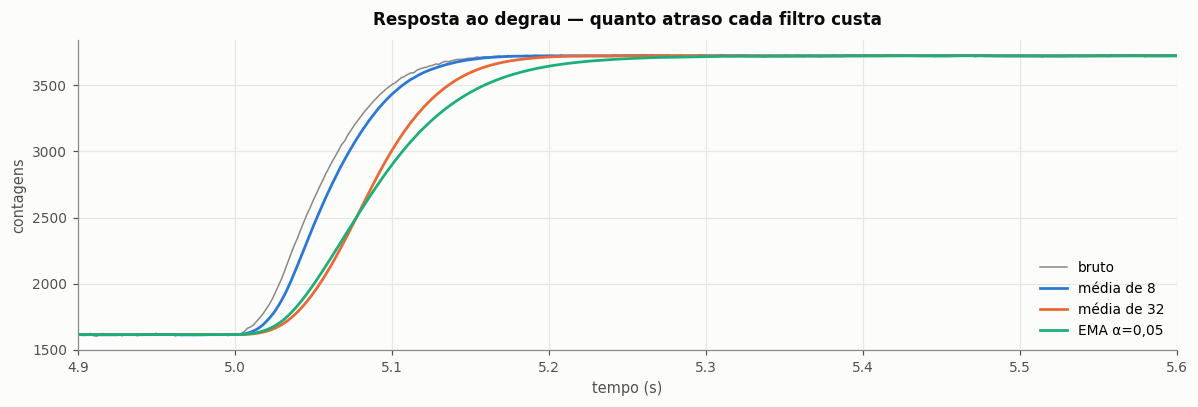

,filtro,σ antes do degrau,tempo até 63 % (ms)
0,bruto,5.76,64.0
1,média de 8,1.23,72.0
2,média de 32,0.92,98.0
3,"EMA α=0,05",1.31,104.0


In [15]:
# --- o preço em latência: a resposta ao degrau ------------------------------
meta, df = carrega("degrau")
x, t = df["bruto"].values, df["t_s"].values
fs = float(meta["taxa_hz"])

candidatos = {"bruto": x, "média de 8": media_movel(x, 8),
              "média de 32": media_movel(x, 32), "EMA α=0,05": ema(x, 0.05)}
cores = {"bruto": MUDO, "média de 8": AZUL, "média de 32": LARANJA, "EMA α=0,05": AQUA}

def tempo_63(y, t, t0=5.0):
    """Tempo até 63 % da transição — a definição usual de constante de tempo."""
    i0 = int(np.argmax(t >= t0))
    base = np.nanmean(y[max(0, i0 - 500):i0]); final = np.nanmean(y[-400:])
    alvo = base + 0.632 * (final - base)
    depois = y[i0:]
    idx = np.where(depois >= alvo)[0]
    return np.nan if len(idx) == 0 else (t[i0 + idx[0]] - t0) * 1000

fig, ax = plt.subplots(figsize=(11, 3.8))
for nome, y in candidatos.items():
    limpa(ax).plot(t, y, color=cores[nome], lw=1.0 if nome == "bruto" else 1.8,
                   label=nome, zorder=1 if nome == "bruto" else 2)
ax.set_xlim(4.9, 5.6)
ax.set_xlabel("tempo (s)"); ax.set_ylabel("contagens")
ax.set_title("Resposta ao degrau — quanto atraso cada filtro custa")
ax.legend(loc="lower right")
fig.tight_layout(); plt.show()

pd.DataFrame([{"filtro": nome,
               "σ antes do degrau": round(float(np.nanstd(y[:int(4.5*fs)])), 2),
               "tempo até 63 % (ms)": round(tempo_63(y, t), 1)}
              for nome, y in candidatos.items()])

### A pegadinha desta tabela

O sinal **bruto** já leva algumas dezenas de milissegundos para chegar aos 63 % —
e ele não tem filtro nenhum. Esse atraso não é seu: parte é a mão levando ~30 ms
para cobrir o sensor, e parte é a **inércia do próprio LDR**, que é um dispositivo
de sulfeto de cádmio e não responde instantaneamente.

Ou seja: **o sensor já é um filtro passa-baixas**, antes de qualquer linha de
código. O atraso que vocês podem atribuir ao filtro é a *diferença* entre a linha
do filtro e a linha do bruto — não o valor absoluto.

Quem esquecer disso vai dimensionar o filtro contra um atraso que não existe, ou
culpar o código por uma lentidão que é física do componente.

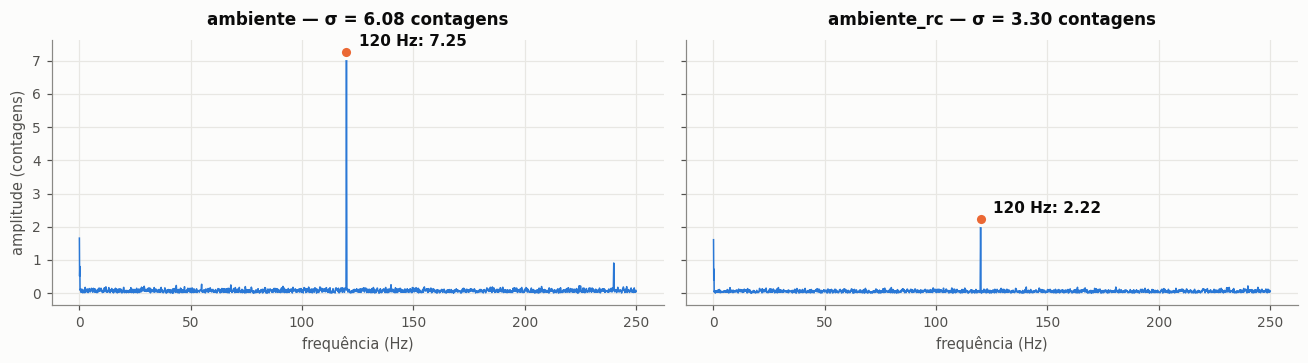

In [16]:
# --- e o condicionamento analógico? Um capacitor faz o trabalho antes do ADC -
fig, eixos = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True)
for ax, cena in zip(eixos, ["ambiente", "ambiente_rc"]):
    meta, df = carrega(cena)
    freq, amp = espectro(df["bruto"].values, float(meta["taxa_hz"]))
    limpa(ax).plot(freq[1:], amp[1:], color=AZUL, lw=1.0)
    j = int(np.argmin(np.abs(freq - 120)))
    ax.plot(freq[j], amp[j], "o", ms=8, color=LARANJA,
            markeredgecolor=SUPERFICIE, markeredgewidth=2, zorder=3)
    ax.annotate(f"120 Hz: {amp[j]:.2f}", xy=(freq[j], amp[j]), xytext=(8, 4),
                textcoords="offset points", color=TINTA, fontsize=10,
                fontweight="semibold")
    ax.set_xlabel("frequência (Hz)")
    ax.set_title(f"{cena} — σ = {df['bruto'].std():.2f} contagens")
eixos[0].set_ylabel("amplitude (contagens)")
fig.tight_layout(); plt.show()

Um capacitor de 1 µF entre o nó de leitura e o GND, junto com a resistência vista
naquele ponto (o paralelo entre os 10 kΩ e o LDR), forma um passa-baixas com
frequência de corte em torno de 40 Hz. Os 120 Hz caem por um fator próximo de 3 —
e caem **antes do ADC**, onde ainda dá para evitar o aliasing.

Note o que o capacitor **não** fez: o σ não foi a zero. O ruído interno do próprio
ADC é gerado depois do capacitor, e nenhum componente colocado no nó de leitura o
alcança. Filtrar antes e filtrar depois resolvem problemas diferentes — e um bom
projeto usa os dois.

### SUA VEZ — 2

Decidam, **com o dado na mão**, e escrevam no README:

1. Qual filtro vai para o firmware do projeto de vocês — média, mediana ou EMA?
2. Com que N (ou α)? Justifiquem citando o σ obtido **e** a latência aceitável
   para a aplicação de vocês.
3. Qual é o piso de σ que vocês *não* conseguem passar por filtragem, e o que
   seria preciso fazer para melhorar além dele?

In [17]:
# SUA VEZ: mexa em N e em alfa e veja σ e latência mudarem juntos.
N_ESCOLHIDO = 8
ALFA_ESCOLHIDO = 0.10
x = carrega("ambiente")[1]["bruto"].values
print(f"bruto            σ = {x.std():.2f}")
print(f"média de {N_ESCOLHIDO:<3}      σ = {np.nanstd(media_movel(x, N_ESCOLHIDO)):.2f}"
      f"   (atraso ≈ {N_ESCOLHIDO/2/500*1000:.0f} ms)")
print(f"mediana de {N_ESCOLHIDO:<3}    σ = {np.nanstd(mediana_movel(x, N_ESCOLHIDO)):.2f}")
print(f"EMA α={ALFA_ESCOLHIDO:<5}      σ = {ema(x, ALFA_ESCOLHIDO).std():.2f}"
      f"   (equivale a uma média de ≈ {2/ALFA_ESCOLHIDO-1:.0f} amostras)")

bruto            σ = 6.08
média de 8        σ = 2.32   (atraso ≈ 8 ms)
mediana de 8      σ = 2.54
EMA α=0.1        σ = 2.23   (equivale a uma média de ≈ 19 amostras)


---
## Parte 4 — Calibrar: de contagem para grandeza física

Filtrar melhora a **precisão** — a repetibilidade. Não melhora a **exatidão** — a
proximidade do valor verdadeiro. Um instrumento pode ser precisíssimo e estar
consistentemente errado, e nenhuma média conserta isso.

A cena `calibracao.csv` traz quatro colunas: a iluminância lida num luxímetro de
referência, a contagem bruta, a conversão ingênua que vocês escreveram no
Laboratório 01 (`bruto × 3300 / 4095`) e o que `analogReadMilliVolts()` devolve,
aplicando a curva de calibração que a Espressif grava no chip na fábrica.

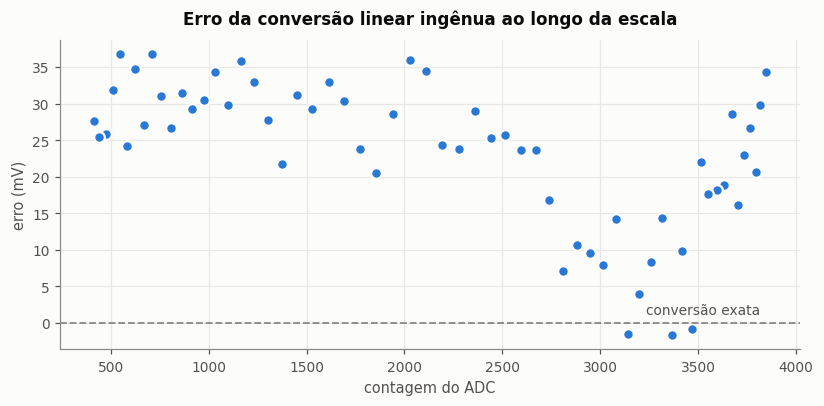

erro médio     =   +23.3 mV
faixa do erro  =    -1.7 a +36.8 mV
em contagens   = até 46 contagens de erro SISTEMÁTICO

para comparar: o σ do ruído em 'ambiente' vale 6.1 contagens.


In [18]:
# --- erro da conversão ingênua ----------------------------------------------
meta_cal, cal = carrega("calibracao")
erro = cal["mv_linear"] - cal["mv_calibrado"]

fig, ax = plt.subplots(figsize=(7.6, 3.8))
limpa(ax).plot(cal["bruto"], erro, "o", ms=7, color=AZUL,
               markeredgecolor=SUPERFICIE, markeredgewidth=1.5)
ax.axhline(0, color=MUDO, lw=1.2, ls="--")
ax.annotate("conversão exata", xy=(cal["bruto"].max(), 0), xytext=(-4, 6),
            textcoords="offset points", ha="right", color=TINTA2, fontsize=9)
ax.set_xlabel("contagem do ADC"); ax.set_ylabel("erro (mV)")
ax.set_title("Erro da conversão linear ingênua ao longo da escala")
fig.tight_layout(); plt.show()

lsb = meta_cal["lsb_mv"]
print(f"erro médio     = {erro.mean():+7.1f} mV")
print(f"faixa do erro  = {erro.min():+7.1f} a {erro.max():+.1f} mV")
print(f"em contagens   = até {abs(erro).max()/lsb:.0f} contagens de erro SISTEMÁTICO")
print(f"\npara comparar: o σ do ruído em 'ambiente' vale "
      f"{carrega('ambiente')[1]['bruto'].std():.1f} contagens.")

**Olhe a ordem de grandeza.** O erro sistemático da conversão ingênua é várias
vezes maior que todo o ruído aleatório que passamos a Parte 3 inteira tentando
reduzir — e ele **não é aleatório**: não tem média zero, não cai com √N, não some
com mediana nenhuma. Ele tem estrutura, porque é a soma de um erro de ganho, um
erro de offset e a não linearidade do conversor.

Foi tempo bem gasto medir o ruído. Mas quem filtra sem calibrar está lustrando um
número errado.

**O conserto é de uma linha:** trocar `analogRead()` seguido de multiplicação por
`analogReadMilliVolts()`, que aplica a curva medida no seu chip específico na
fábrica e gravada na eFuse dele.

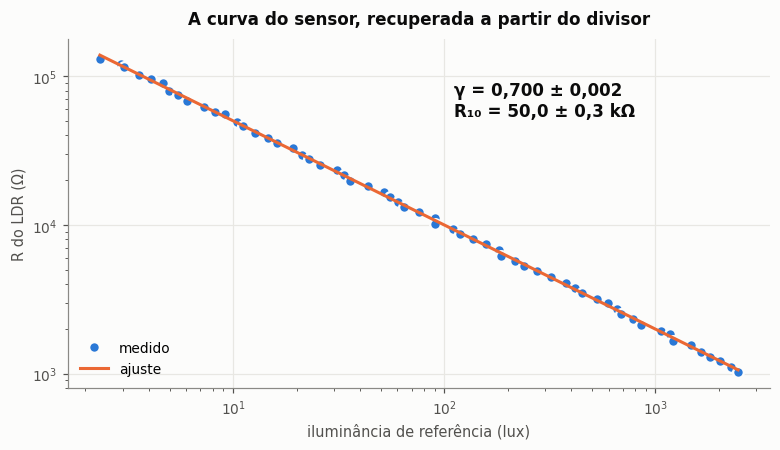

expoente γ estimado  = 0.700 ± 0.002    (modelo do componente: 0,7)
R a 10 lux estimado  = 50.0 ± 0.3 kΩ   (modelo do componente: 50 kΩ)

60 pontos e um ajuste por mínimos quadrados recuperam os dois parâmetros
dentro da incerteza — apesar de o luxímetro de referência declarar 4 %.


In [19]:
# --- do divisor de volta para o sensor --------------------------------------
# 3V3 -> R_FIXO -> nó -> LDR -> GND  =>  V_no = V_alim * R_LDR/(R_FIXO + R_LDR)
# Invertendo:                             R_LDR = R_FIXO * V_no/(V_alim - V_no)
R_FIXO, V_ALIM = 10_000.0, 3300.0
v = cal["mv_calibrado"].values
r_ldr = R_FIXO * v / (V_ALIM - v)
lux = cal["lux_ref"].values

# Modelo do LDR: R = R10*(lux/10)^(-gama). Em log-log vira uma reta,
# e o expoente gama é o negativo da inclinação.
coef, cov = np.polyfit(np.log10(lux / 10.0), np.log10(r_ldr), 1, cov=True)
gama_estimado, r10_estimado = -coef[0], 10 ** coef[1]
# O ajuste é uma ESTIMATIVA: ela também tem incerteza, e vale declará-la.
inc_gama = np.sqrt(cov[0, 0])
inc_r10 = r10_estimado * np.log(10) * np.sqrt(cov[1, 1])

fig, ax = plt.subplots(figsize=(7.2, 4.2))
limpa(ax).loglog(lux, r_ldr, "o", ms=7, color=AZUL,
                 markeredgecolor=SUPERFICIE, markeredgewidth=1.5, label="medido")
lux_liso = np.geomspace(lux.min(), lux.max(), 100)
ax.loglog(lux_liso, r10_estimado * (lux_liso / 10.0) ** (-gama_estimado),
          color=LARANJA, lw=2, label="ajuste")
rotulo = (f"γ = {gama_estimado:.3f} ± {inc_gama:.3f}\n"
          f"R₁₀ = {r10_estimado/1000:.1f} ± {inc_r10/1000:.1f} kΩ").replace(".", ",")
ax.annotate(rotulo, xy=(0.55, 0.78), xycoords="axes fraction", color=TINTA,
            fontsize=11, fontweight="semibold")
ax.set_xlabel("iluminância de referência (lux)"); ax.set_ylabel("R do LDR (Ω)")
ax.set_title("A curva do sensor, recuperada a partir do divisor")
ax.legend(loc="lower left")
fig.tight_layout(); plt.show()

print(f"expoente γ estimado  = {gama_estimado:.3f} ± {inc_gama:.3f}"
      f"    (modelo do componente: 0,7)")
print(f"R a 10 lux estimado  = {r10_estimado/1000:.1f} ± {inc_r10/1000:.1f} kΩ"
      f"   (modelo do componente: 50 kΩ)")
print(f"\n60 pontos e um ajuste por mínimos quadrados recuperam os dois parâmetros"
      f"\ndentro da incerteza — apesar de o luxímetro de referência declarar 4 %.")

A reta em log-log é a assinatura de uma **lei de potência**: $R = R_{10}\,(L/10)^{-\gamma}$.
Ajustar uma reta aos logaritmos é o modo honesto de estimar os dois parâmetros do
sensor a partir de medidas — e note que a curva **não é linear** em escala normal.
Toda a conversão contagem → lux depende disso.

Repare também no que o gráfico mostra sobre resolução: nas iluminâncias altas os
pontos se amontoam, porque ali o divisor quase não muda de tensão. **O mesmo LSB
vale poucos lux no escuro e centenas de lux no claro.** É por isso que a cena
`forte` tinha σ baixo em contagens: precisão em contagens não é precisão em lux.

In [20]:
# --- fechando o ciclo: a telemetria em grandeza física ----------------------
def contagem_para_lux(bruto, lsb_mv, gama=gama_estimado, r10=r10_estimado):
    v = np.clip(bruto * lsb_mv, 1.0, V_ALIM - 1.0)
    r = R_FIXO * v / (V_ALIM - v)
    return 10.0 * (r / r10) ** (-1.0 / gama)

linhas = []
for cena in ["escuro", "ambiente", "forte"]:
    meta, df = carrega(cena)
    lx = contagem_para_lux(df["bruto"].values, meta["lsb_mv"])
    c = df["bruto"].values
    linhas.append({
        "cena": cena,
        "σ (contagens)": round(c.std(), 2),
        "lux médio": round(float(np.mean(lx)), 1),
        "σ (lux)": round(float(np.std(lx)), 2),
        "σ relativo (%)": round(float(np.std(lx) / np.mean(lx) * 100), 2),
    })
pd.DataFrame(linhas)

,cena,σ (contagens),lux médio,σ (lux),σ relativo (%)
0,escuro,2.68,2.5,0.04,1.42
1,ambiente,6.08,183.6,1.63,0.89
2,forte,2.62,2435.8,25.54,1.05


### A tabela que fecha a aula

Comparem `escuro` e `forte`: σ em contagens praticamente idêntico — 2,68 contra
2,62. Do ponto de vista elétrico, os dois canais são igualmente ruidosos. Mas em
incerteza **relativa** da grandeza que interessa, `escuro` é cerca de 35 % pior.

E olhem `ambiente`: σ em contagens **mais que o dobro** dos outros dois, e ainda
assim a **melhor** incerteza relativa da tabela. O canal mais ruidoso é o que mede
melhor.

Não há contradição — as duas colunas medem coisas diferentes. σ em contagens é o
ruído **elétrico**. σ relativo em lux é a incerteza da **medida**, e ela depende
também da inclinação da curva no ponto de operação. Perto dos 185 lux o divisor de
10 kΩ está na sua região mais sensível: muita variação de tensão para pouca
variação de luz. No escuro e na luz forte ele está achatado, e o mesmo LSB passa a
valer muito mais lux.

**A consequência é uma decisão de projeto, não um detalhe de montagem.** O resistor
fixo do divisor escolhe *onde na faixa* o instrumento é bom. Trocá-lo desloca essa
janela. Escolham pela faixa que o problema de vocês exige — não pelo que sobrou na
gaveta.

E, sobretudo: **reduzir o ruído elétrico não era o objetivo.** Era reduzir a
incerteza da medida. São coisas diferentes, e a tabela acima mostra que otimizar a
primeira sem olhar a segunda pode levar à escolha errada.

### SUA VEZ — 3

1. Refaçam a última tabela para `estavel` e `saturado`. O que acontece com o σ em
   lux da cena saturada, e por quê?
2. Qual faixa de iluminância o divisor de 10 kΩ mede bem? Se o projeto da equipe
   precisar operar em outra faixa, que resistor vocês usariam?
3. Substituam a conversão do sketch do Laboratório 01 pela calibrada e mostrem
   uma linha do novo CSV, em grandeza física.

---
## Parte 5 — O que vai para o repositório

Na pasta `aula05` do repositório da equipe:

- [ ] Este notebook **executado**, com os gráficos visíveis
- [ ] `README.md` com: σ antes e depois da filtragem, o N (ou α) escolhido e a
      justificativa citando σ **e** latência
- [ ] As respostas das três seções **SUA VEZ**
- [ ] O sketch do Laboratório 01 atualizado: filtro escolhido + conversão calibrada,
      com o CSV saindo em grandeza física
- [ ] A frase que faltava no Lab 01: **qual é a incerteza da medida que vocês
      publicam?** Sem ela, o número no CSV é uma opinião.

**Mestrandos, adicionalmente (entrega no SIGAA):** orçamento de erro do canal —
quantização, ruído aleatório, erro de ganho e offset, não linearidade e deriva,
cada um com sua ordem de grandeza e a justificativa de qual domina. Estimem o ENOB
efetivo e discutam, em meia página, a consequência disso para a escolha do sensor
e da faixa de operação do projeto da equipe.

---

### O fio que continua

A linha de CSV que sai do sketch de vocês agora tem procedência, unidade física e
incerteza. Em **19/10** ela vira campanha de coleta; no **Módulo 3**, dataset de
treinamento. Modelo nenhum conserta dado mal medido — ele apenas aprende o erro
com muita convicção.

**Próxima aula, 31/08:** barramentos e interfaces locais — UART, I²C, SPI e 1-Wire.
Ou seja: o que muda quando o ADC não é mais seu, e sim de dentro do sensor.